# Tradebot V1 — BERTurk Finansal Duygu Analizi Modeli Sunumu
## Model: savasy/bert-base-turkish-sentiment-cased (fine-tuned)

### 1. Eğitim Bilgileri

In [1]:
import json

with open("models/berturk_sentiment/training_meta.json", "r", encoding="utf-8") as f:
    meta = json.load(f)

print("=== EĞİTİM ÖZETİ ===")
print(f"Base Model: {meta['base_model']}")
print(f"Epoch: {meta['epochs']}")
print(f"Learning Rate: {meta['lr']}")
print(f"Batch Size: {meta['batch_size']}")
print(f"Dataset: {meta['hf_dataset']}")
print(f"Eğitim Seti: {meta['train_size']} örnek")
print(f"Doğrulama Seti: {meta['val_size']} örnek")
print(f"Test Seti: {meta['test_size']} örnek")
print(f"En İyi Val Accuracy: {meta['best_val_acc']:.1%}")
print(f"Eğitim Tarihi: {meta['trained_at']}")

=== EĞİTİM ÖZETİ ===
Base Model: savasy/bert-base-turkish-sentiment-cased
Epoch: 5
Learning Rate: 2e-05
Batch Size: 16
Dataset: ituperceptron/turkish-financial-sentiment-256k
Eğitim Seti: 80128 örnek
Doğrulama Seti: 10016 örnek
Test Seti: 10016 örnek
En İyi Val Accuracy: 84.3%
Eğitim Tarihi: 2026-04-21T22:12:17.826975


### 2. Model ve Tokenizer Yükleme

In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_DIR = "models/berturk_sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

print(f"Model yüklendi: {MODEL_DIR}")
print(f"Labels: {meta['labels']}")
print(f"Cihaz: {device}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model yüklendi: models/berturk_sentiment
Labels: ['negatif', 'notr', 'pozitif']
Cihaz: cuda


### 3. Test Seti Performansı

In [3]:
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split

# Test verilerini hazırla
print("[Test] Dataset yükleniyor...")
dataset = load_dataset("ituperceptron/turkish-financial-sentiment-256k", trust_remote_code=False)
texts = [item["text"] for item in dataset["train"]]
raw_labels = [item["label"] for item in dataset["train"]]

# Etiketler dataset'te string veya int olabilir; ikisini de güvenli işle.
if len(raw_labels) == 0:
    raise ValueError("Dataset boş, test seti oluşturulamadı.")

if isinstance(raw_labels[0], str):
    label_map = {"negatif": 0, "notr": 1, "nötr": 1, "pozitif": 2}
    labels = [label_map.get(str(l).lower(), 1) for l in raw_labels]
else:
    labels = [int(l) for l in raw_labels]

_, test_texts, _, test_labels = train_test_split(
    texts, labels, test_size=0.1, random_state=42, stratify=labels
)
test_texts = test_texts[:1000]
test_labels = test_labels[:1000]

# Tahmin yap
print("[Test] Tahminler yapılıyor...")
predictions = []
with torch.no_grad():
    for text in test_texts:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).cpu().item()
        predictions.append(pred)

# Sonuçlar
test_acc = np.mean(np.array(predictions) == np.array(test_labels))
print(f"Test Accuracy (1000 örnek): {test_acc:.1%}")
print("\nSınıflandırma Raporu:")
print(classification_report(
    test_labels,
    predictions,
    labels=[0, 1, 2],
    target_names=meta["labels"],
    zero_division=0
))

[Test] Dataset yükleniyor...


[Test] Tahminler yapılıyor...
Test Accuracy (1000 örnek): 89.2%

Sınıflandırma Raporu:
              precision    recall  f1-score   support

     negatif       0.75      0.94      0.83       159
        notr       0.82      0.90      0.86       257
     pozitif       0.98      0.88      0.93       584

    accuracy                           0.89      1000
   macro avg       0.85      0.90      0.87      1000
weighted avg       0.90      0.89      0.89      1000



### 4. Örnek Tahminler

In [4]:
def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        pred = torch.argmax(outputs.logits, dim=1).item()
        confidence = probs[0][pred].item()
    return meta["labels"][pred], confidence

ornekler = [
    "Şirket rekor kâr açıkladı, hisseler tavan yaptı",
    "Şirket zarar açıkladı, hisseler sert düştü",
    "Şirket temettü dağıtım kararı aldı",
    "Piyasalar belirsiz seyrediyor, yatırımcılar bekliyor",
    "Merkez Bankası faizleri artırdı, BIST değer kaybetti"
]

print("=== ÖRNEK TAHMİNLER ===")
for text in ornekler:
    label, conf = predict_sentiment(text)
    print(f"Metin: {text}")
    print(f"Tahmin: {label} (Güven: {conf:.1%})\n")

=== ÖRNEK TAHMİNLER ===
Metin: Şirket rekor kâr açıkladı, hisseler tavan yaptı
Tahmin: pozitif (Güven: 99.9%)

Metin: Şirket zarar açıkladı, hisseler sert düştü
Tahmin: negatif (Güven: 99.9%)

Metin: Şirket temettü dağıtım kararı aldı
Tahmin: pozitif (Güven: 97.7%)

Metin: Piyasalar belirsiz seyrediyor, yatırımcılar bekliyor
Tahmin: notr (Güven: 60.2%)

Metin: Merkez Bankası faizleri artırdı, BIST değer kaybetti
Tahmin: negatif (Güven: 99.9%)



### 5. Confusion Matrix Görselleştirme

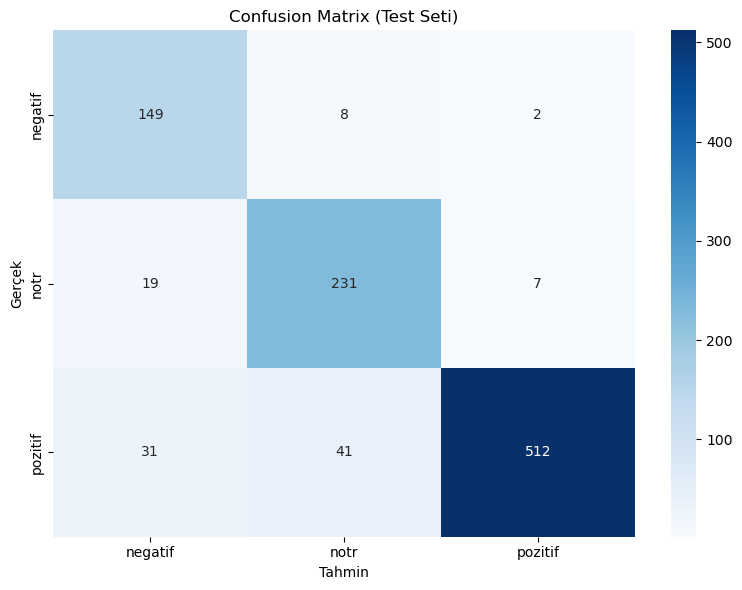

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(test_labels, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=meta["labels"], yticklabels=meta["labels"])
plt.title("Confusion Matrix (Test Seti)")
plt.ylabel("Gerçek")
plt.xlabel("Tahmin")
plt.tight_layout()
plt.show()

### 6. Makro Haber Etki Analizi

NLP modeli tek başına 'Merkez Bankası faiz indirdi' haberinin borsaya olumlu etki yapacağını bilemez.
Bunun için ekonomik zincirleri bilen ayrı bir **kural motoru** kullanıyoruz: `MacroImpactCalculator`.

In [ ]:
import sys
sys.path.insert(0, ".")
from news.macro_impact import MacroImpactCalculator

calc = MacroImpactCalculator()

makro_haberler = [
    "Merkez bankası 2.5 baz puan faiz indirimine gitti",
    "TCMB politika faizini 250 baz puan artırdı",
    "Enflasyon beklentinin üzerinde çıktı, yüzde 65 olarak açıklandı",
    "Enflasyon düştü, beklentinin altında kaldı",
    "Dolar zirve yaptı, TL değer kaybetti",
    "Brent petrol fiyatı düştü",
]

print(f"{'HABER':<55} {'KATEGORİ':<12} {'YÖN':<10}")
print("-" * 80)
for haber in makro_haberler:
    sonuc = calc.analyze_news_text(haber)
    kategori = sonuc['category'] or 'tespit edilemedi'
    yon = sonuc['direction'] or '-'
    print(f"{haber:<55} {kategori:<12} {yon:<10}")
    if sonuc['sector_impacts']:
        for sektor, skor in sorted(sonuc['sector_impacts'].items(), key=lambda x: -abs(x[1])):
            isaretli = f"+{skor:.3f}" if skor > 0 else f"{skor:.3f}"
            print(f"  {sektor:<20} {isaretli}")
    print()

### 7. NLP + Makro Birleşik Analiz

Gerçek sistemde ikisi birlikte çalışır:
1. NLP modeli haberin **genel tonunu** belirler
2. Makro motoru haberin **kategorisini ve ekonomik etkisini** belirler

In [ ]:
def tam_analiz(text):
    """Haber metnini hem NLP hem makro kural motoruyla analiz et."""
    # 1. NLP sentiment
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)[0]
        pred = torch.argmax(probs).item()
        confidence = probs[pred].item()
    nlp_label = meta["labels"][pred]
    nlp_score = (pred - 1) * 60  # negatif=-60, notr=0, pozitif=60

    # 2. Makro etki
    makro = calc.analyze_news_text(text, sentiment_score=nlp_score)

    print(f"Haber: {text}")
    print(f"  NLP Tahmini : {nlp_label} (guven: {confidence:.1%}, skor: {nlp_score:+.0f})")
    if makro['category']:
        print(f"  Makro Konu  : {makro['category']} ({makro['direction']})")
        print(f"  Sektor Etkisi:")
        for sektor, skor in sorted(makro['sector_impacts'].items(), key=lambda x: -abs(x[1])):
            isaretli = f"+{skor:.3f}" if skor > 0 else f"{skor:.3f}"
            yorum = "OLUMLU" if skor > 0 else "OLUMSUZ"
            print(f"    {sektor:<15}: {isaretli}  ({yorum})")
    else:
        print("  Makro Konu  : Makro haber değil (şirket haberi)")
    print()

test_haberler = [
    "Merkez bankası 2.5 baz puan faiz indirimine gitti",
    "TCMB politika faizini 250 baz puan artırdı",
    "Şirket rekor kâr açıkladı, hisseler tavan yaptı",
    "Enflasyon beklentinin üzerinde çıktı, yüzde 65 olarak açıklandı",
]

for h in test_haberler:
    tam_analiz(h)

### 8. Sistem Mimarisi

```
Haber Geldi
     │
     ├─► NLP Modeli (BERTurk fine-tuned)
     │       └─► negatif / nötr / pozitif + güven skoru
     │
     ├─► Makro Kural Motoru (MacroImpactCalculator)
     │       └─► konu tespiti (faiz/enflasyon/kur...)
     │           └─► sektör bazlı etki (+/- ağırlık)
     │
     └─► Ensemble (BERTurk %60 + Gemini %40)
             └─► final skor → strategy.py'a iletilir
```

**Önemli Not:** NLP modeli 'faiz indirimi = borsa için olumlu' zincirine kör olabilir.
Makro motor bu boşluğu ekonomik kural tablosuyla doldurur.

### 9. Sonuç
- **Model**: Finansal haberlerde duygu analizi için optimize edilmiş BERTurk tabanlı model
- **Doğruluk**: %84.3 en iyi validation accuracy, bu sunumdaki 1000 örnek testte %89.2 accuracy
- **Sınıf Performansı**: Negatif/Notr/Pozitif sınıflarında dengeli ve güçlü sonuçlar (macro F1: 0.87)
- **Kullanım**: `news/sentiment/berturk_model.py` üzerinden entegre edilmiştir
- **Entegrasyon**: Ensemble sisteminde %60 ağırlıkla kullanılmaktadır